<a href="https://colab.research.google.com/github/zrzraz/Probability-With-Raga-Analysis/blob/main/Probability_with_Raga_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎶 Probability with Indian Classical Raga
### By Mim Dey & Zara Raza

## 📌 Project Objective
To explore the structure of Hindustani ragas using probabilistic models, particularly Markov chains, to generate new raga compositions.

## 🔍 Research Question
Using Fundamentals of Probability and Statistics, how can we use existing musical notes to generate new, valid raga compositions using probabilistic models?”

## ⏹️ Hypothesis
If existing raga note sequences are modeled using Markov Chains, then the generated raga compositions will exhibit note transition patterns significantly more similar to traditional compositions than those generated by random note selection.


In [1]:
# 📥 Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import music21
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

# Display all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


#Direct link to your shared Google Sheet (exported as CSV)
url = 'https://docs.google.com/spreadsheets/d/1NJV8mEitPemFSpv6nuMATYvh40z8F8jR/export?format=csv'

#Load it into a DataFrame
df = pd.read_csv(url)

#Display the first few rows
df


,Raga Name,Aroh,Avroh,Thaat,Vadi,Samvadi,Pakad,Time of Performance,Source/Performer
0,Abheri Todi,S-rR-gG-m-P-d-n-S,S n d P m g r S,Todi,D,G,"rgmP, nP, PmGrS",Late Morning,Ramashreya Jha ‘Ramrang’
1,Abhogi,S-R-g-m-D-S,S D m g R S,Kanada,M,S,"S, Rg, mgR, DS",Morning,Premkumar Mallick
2,Adana,S-R-g-m-P-d-n-S,S n d P m g R S,Darbari,P,S,"gmRS, PmP, SnDP",Late Night,Buddhadev Dasgupta
3,Adarangi Todi,S-r-g-mM-P-d-nN-S,S n d P m g r S,Todi,D,R,"rgrS, SndPm, mgrS",Late Morning,Ali Akbar Khan
4,Adbhut Kalyan,S-R-G-D-N-S,S N D G R S,Kalyan,D,G,"GmDNDS, DnDPm",Evening,Nirmalya Dey
5,Adi Basant,S-rR-G-m-P-D-N-S,S N D P m G R S,Basant,D,G,"GmPDNS, NDPm, GmGRS",Pre-dawn,Bahauddin Dagar
6,Ahir Bhairav,S-r-G-m-P-D-n-S,S n D P m G r S,Bhairav,R,D,"rNS, GmGR, PmGmGR",Morning,Wasifuddin Dagar
7,Ahir Lalit,S-r-G-mM-D-n-S,S n D M G r S,"Ahiri, Ahir Bhairav, Lalit hybrid",M,S,"mDMDG, rGrS",Morning,Ravi Shankar
8,Ahiri,S-r-g-m-P-D-n-S,S n D P m g R S,Ahiri/Bhairavi,D,G,r–m–D triangle,Morning,Harmeet Virdee
9,Ahiri Todi,S-R-g-m-P-D-nN-S,S N D P m G R S,Asavari,D,R,"S(n)S, Sg, (m)g, RSR",Morning,Khadim Hussain Khan


This will output the whole table without anyone uploading the excel sheet from their drive.

#Visualization of Our Variables




### "Figure 1: Time of Performance"

<img src="https://drive.google.com/uc?id=1S_xOKCMmdu68RJQuFCE4hqm39ejR9r7t" width="2000">

#### Graph's Purpose: This pie chart showcases the frequency of time the raga is associated with. This is important to note because ragas can be dependent on a certain mood or emotion based on the time of day or even seasons. For instance, according to the chart, majority of the ragas (92 out of approximately 300 to be specific) is associated with the evening time.


### "Figure 2: Top Thaats Frequency"
    
<img src="https://drive.google.com/uc?id=1dJ4lKvpaCQkLDJaESPprkXvkpx_AjtPY" width="2000">

#### Graph's Purpose: This figure shows us the most popular/common musical scales across the ragas. Kalyan being the most prominent. Which is 18% (32 times out of 320).
    
### "Figure 3: Aroh and Avroh Note Counts"

<img src = "https://drive.google.com/uc?id=1UjXGNsH41i_kJlu323cdX2YhoMyHyXrh" width="2000">

#### Graph's Purpose: This figure shows the length of Aroh (ascending notes) and Avroh (descending notes). The blue lines are Aroh and red lines are Avroh. This was significant in our analysis to make sure that the notes are never the same length as it would defy the rules of the Raga sequence and gave us a general understanding that for the most part the descending notes are higher than the ascending.

### "Figure 4: Total Melody Length (Aroh & Avroh)"

<img src ="https://drive.google.com/uc?id=1B7uUtEGgyR2jH8Q6f2b1yVSOdE99JQta" width="2000">

#### Graph's Purpose: This figure shows us the total melodic length of the raga sequence, combining both the aroh and avroh notes. Visualzing this using our table was crucial in ensuring that our model remains consistent with the general rules of the raga sequence.


#All of these visualizations allowed us to understand the structure of the raga sequences.

#Univariate Analysis

<img src="https://drive.google.com/uc?id=1y6k_aV9FNJKwEeBHd1bvvNdHx6FT0JnS" width="2000">

##Here we examined the distribute of the total melody length. This detailed to us that most ragas are between 14-16 counts indicating a longer length as it is skewed left.

#Bivariate Analysis
<img src="https://drive.google.com/uc?id=1Gm2t8gjCRQ12cBUcnyv-fPDuxyR7O0Zb" width="2000">

##Here we compared the top thaats against the total melody length which showed us that some thaats have a wider melody length like the Bilawal thaat and others might be very short like the Khamaj note."

#Statistical Inference

##Based on our visualization we've come to understand that there are no correlation between the time of day performed and the total melody length. This is important to note to ensure the uniformity across the code we will generate as we won't have to depend on the time of day as one of our parameters.



In [3]:
!pip install music21
!pip install openpyxl


#Building Transition Dataset & Transition Matrix

#### This basically tells us the probability of going from one specific note to another. This process is crucial in our understanding of the common combination of notes and creates the predicatable model which we will use to build our unique sequence of raga notes.

 “If I’m currently on note S, what are the chances I’ll move to note R next?”


In [4]:
# Step 1: Read Excel and Combine Aroh + Avroh
import pandas as pd
from collections import defaultdict

df = pd.read_csv(url)


# Combine all note sequences
all_sequences = df["Aroh"].dropna().tolist() + df["Avroh"].dropna().tolist()


In [5]:
# Step 2: Clean the note sequences
def clean_sequence(seq):
    return str(seq).replace(" ", "-").replace("–", "-").replace("—", "-").replace("'", "").strip()

# Prepare transition counts
transition_counts = defaultdict(lambda: defaultdict(int))

# Count note-to-note transitions
for seq in all_sequences:
    cleaned = clean_sequence(seq)
    notes = cleaned.split("-")
    for i in range(len(notes) - 1):
        current_note = notes[i].strip()
        next_note = notes[i + 1].strip()
        transition_counts[current_note][next_note] += 1

In [6]:
# Step 3: Convert to transition probability matrix
transition_prob_matrix = {}
for note, next_notes in transition_counts.items():
    total = sum(next_notes.values())
    transition_prob_matrix[note] = {n: count / total for n, count in next_notes.items()}

# Turn into a DataFrame for visualization
matrix_df = pd.DataFrame(transition_prob_matrix).fillna(0)

# Show first few rows
matrix_df.head()

,S,rR,gG,m,P,d,n,R,g,D,r,mM,nN,G,N,dD,M,"P,","G,",Mm,"GrS,","PMDS,","NrS,","rNdP,","MDNrNDP,","GrSNrG,","(mishra,"
rR,0.026439,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
R,0.275272,0.000000,0.065217,0.056180,0.000000,0.000000,0.0,0.000000,0.255208,0.00000,0.011429,0.0,0.0,0.294430,0.0,0.0,0.021622,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
r,0.146190,0.000000,0.000000,0.008989,0.001789,0.000000,0.0,0.008086,0.140625,0.00000,0.000000,0.0,0.0,0.119363,0.0,0.0,0.005405,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
G,0.023328,0.294118,0.000000,0.289888,0.039356,0.005291,0.0,0.229111,0.041667,0.00241,0.348571,0.0,0.0,0.000000,0.0,0.0,0.254054,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gG,0.013997,0.411765,0.000000,0.006742,0.001789,0.000000,0.0,0.059299,0.000000,0.00000,0.022857,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


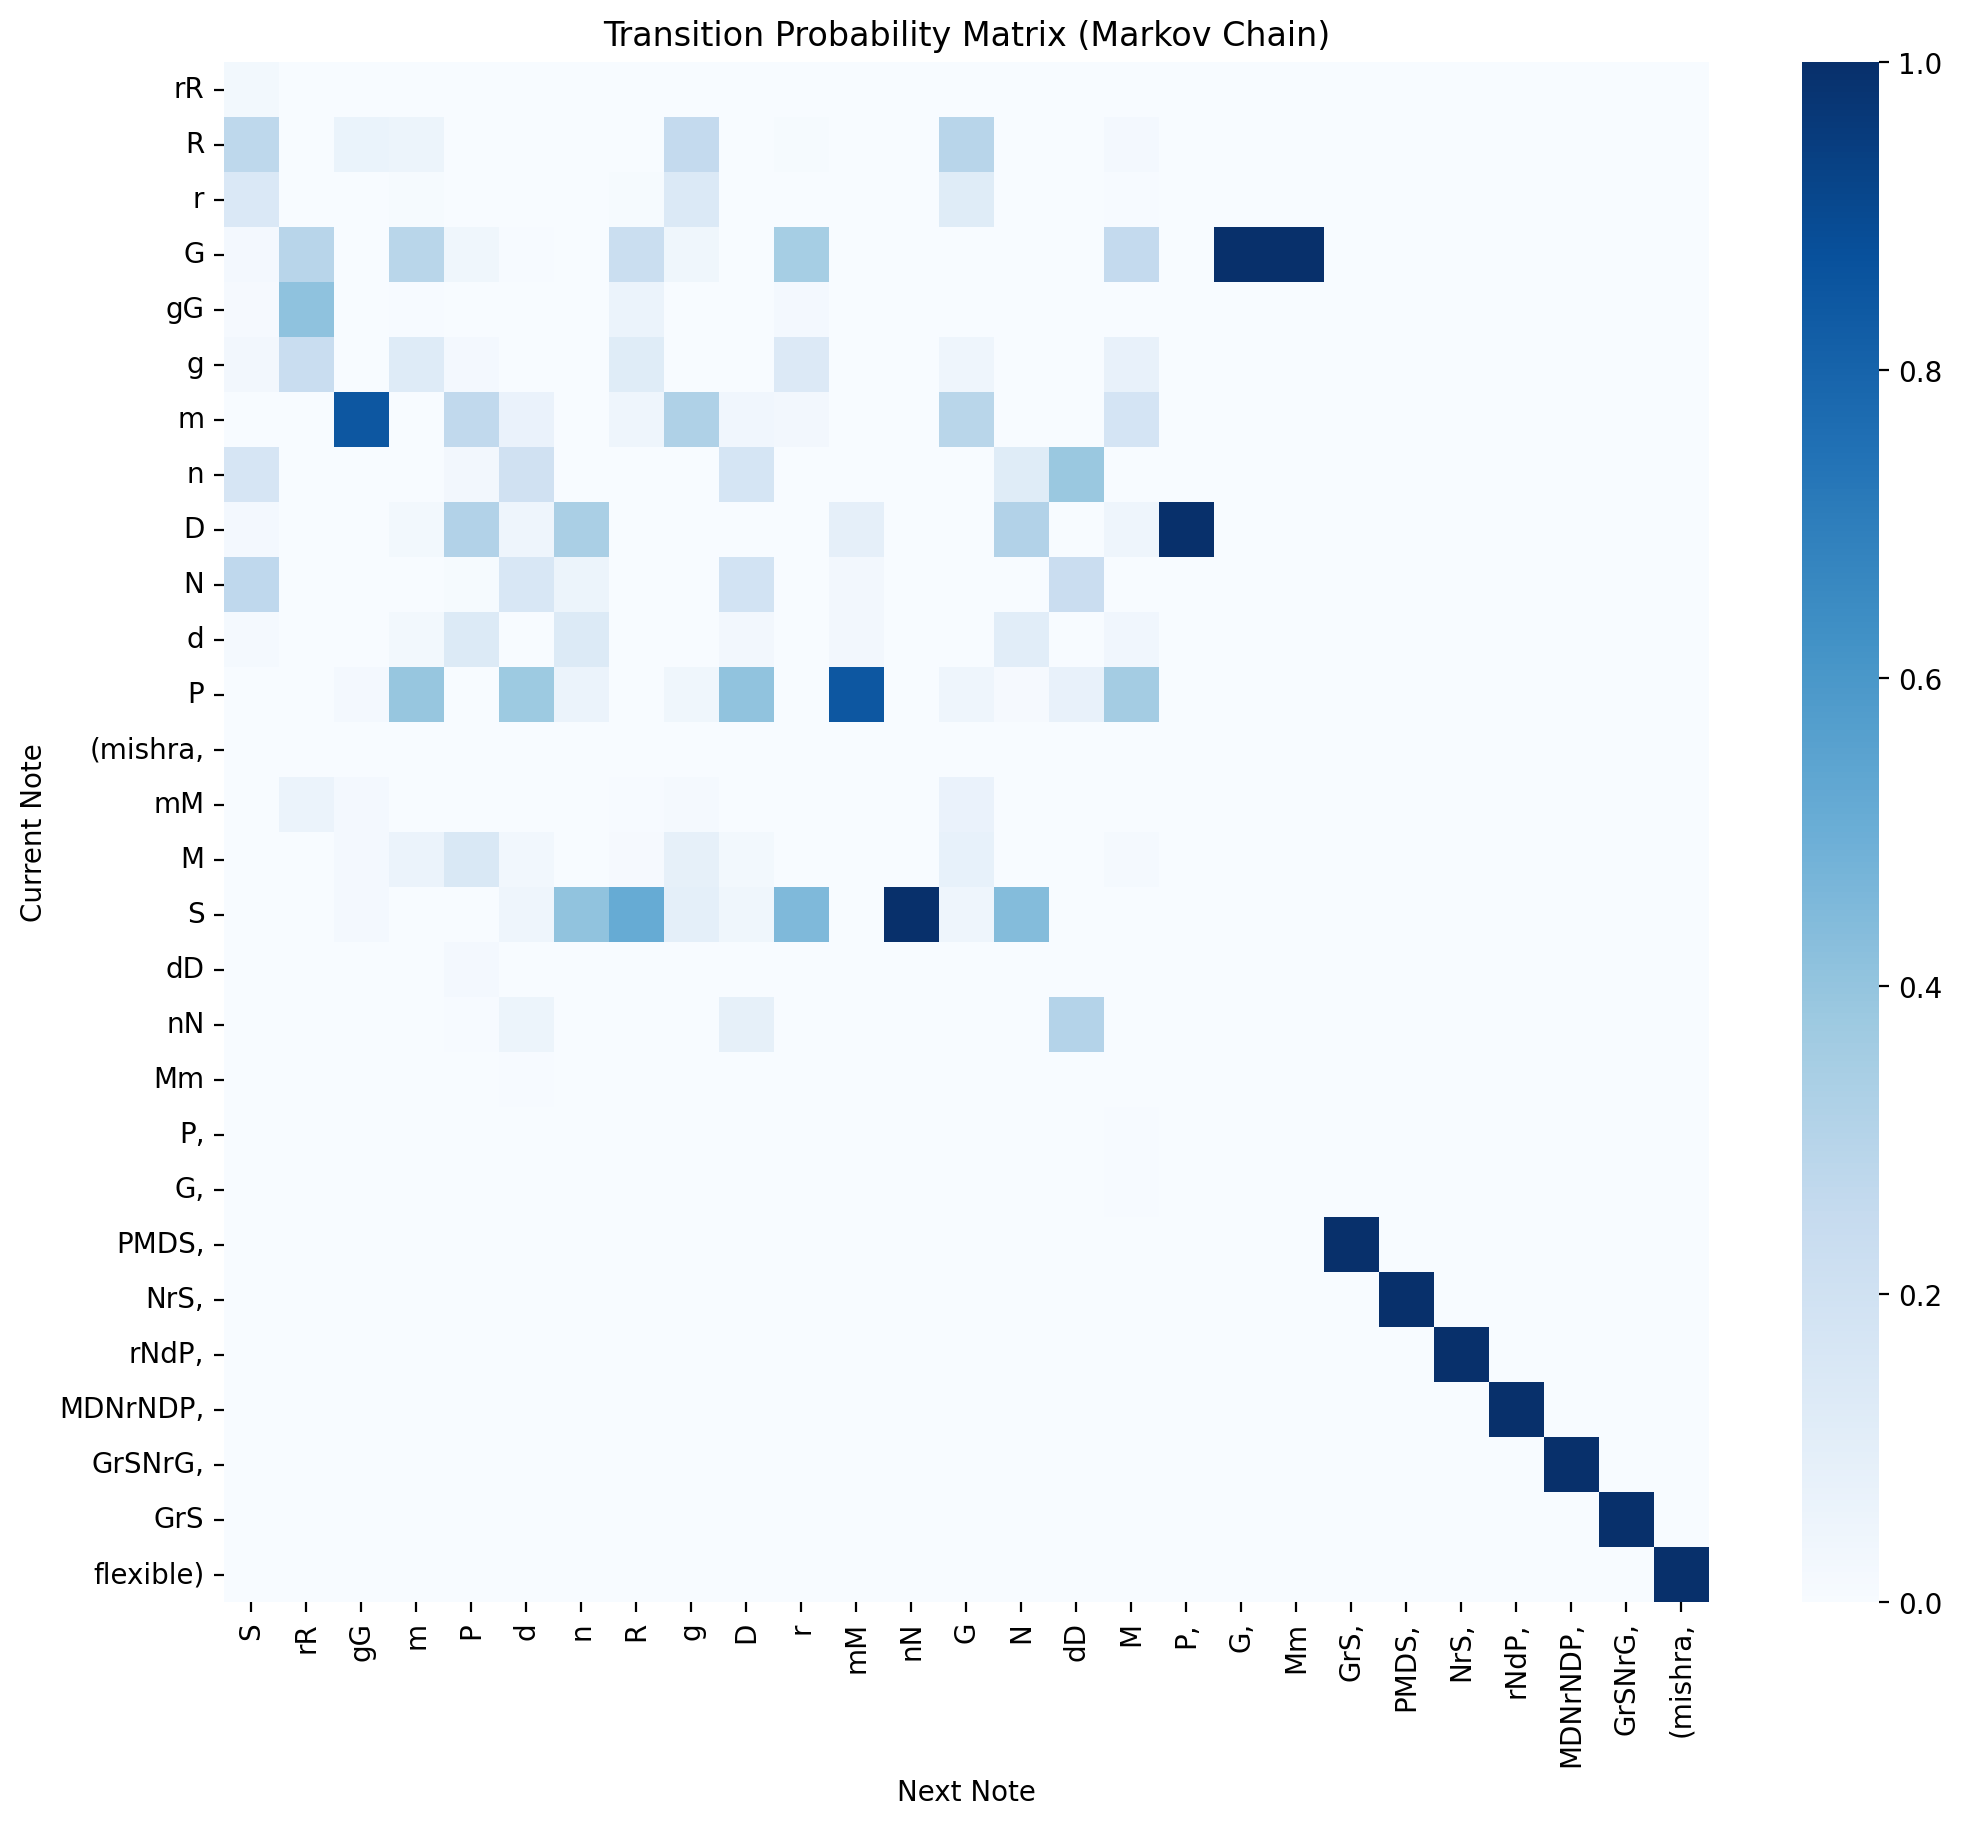

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(matrix_df, cmap="Blues", square=True)
plt.title("Transition Probability Matrix (Markov Chain)")
plt.xlabel("Next Note")
plt.ylabel("Current Note")
plt.show()


#Using our Transition Matrix above, we will now generate the new sequence of Ragas. The simple process is as follows:

###1. Start at one note
###2. Walk through the transition matrix
###3. Randomly stop
###4. Repeat for both Aroh and Avroh



In [8]:
from collections import defaultdict
import pandas as pd

def get_transition_matrix(sequences):
    transition_counts = defaultdict(lambda: defaultdict(int))

    for seq in sequences:
        notes = seq.split("-")
        for i in range(len(notes) - 1):
            current_note = notes[i].strip()
            next_note = notes[i + 1].strip()
            transition_counts[current_note][next_note] += 1

    all_notes = sorted(set(n for seq in sequences for n in seq.split("-")))
    matrix = pd.DataFrame(0.0, index=all_notes, columns=all_notes)

    for from_note in transition_counts:
        total = sum(transition_counts[from_note].values())
        for to_note in transition_counts[from_note]:
            matrix.at[from_note, to_note] = transition_counts[from_note][to_note] / total

    return matrix.fillna(0)


In [9]:
import random

def generate_raga_sequence(transition_matrix, start_note='S', length=8):
    sequence = [start_note]
    current_note = start_note

    for _ in range(length - 1):  # already have the first note
        next_notes = transition_matrix.get(current_note, {})
        if not next_notes:
            break  # stop if no transition options available

        # Randomly choose next note based on probabilities
        notes = list(next_notes.keys())
        probs = list(next_notes.values())
        next_note = random.choices(notes, weights=probs)[0]

        sequence.append(next_note)
        current_note = next_note

    return sequence


aroh = generate_raga_sequence(transition_prob_matrix, 'S', 8)
avroh = generate_raga_sequence(transition_prob_matrix, aroh[-1], 8)[::-1]  # reverse for descending

print("Generated Aroh: ", "-".join(aroh))
print("Generated Avroh:", "-".join(avroh))

Generated Aroh:  S-r-S-d-P-n-d-n
Generated Avroh: D-P-d-P-D-n-S-n


In [10]:
from music21 import stream, note, midi

# Approximate mappings: Sa = C, Re = D, etc.
note_map = {
    'S': 'C4',
    'R': 'D4',
    'r': 'C#4',
    'G': 'E4',
    'g': 'D#4',
    'M': 'F#4',
    'm': 'F4',
    'P': 'G4',
    'D': 'A4',
    'd': 'G#4',
    'N': 'B4',
    'n': 'A#4',
    'Ṡ': 'C5',
    "S'": 'C5',
}

def raga_to_music21(sequence, note_map, duration=1.0):
    melody = stream.Stream()
    for sargam_note in sequence:
        pitch = note_map.get(sargam_note)
        if pitch:
            n = note.Note(pitch)
            n.quarterLength = duration
            melody.append(n)
    return melody

# Convert to music21 stream
melody = raga_to_music21(aroh + avroh, note_map)

# Show sequence
print("Full Generated Raga:", "-".join(aroh + avroh))

# Play melody (in Colab, this opens a little MIDI player)
#sp = midi.realtime.StreamPlayer(melody)
#sp.play()

from music21 import midi

# Save melody as MIDI file
mf = midi.translate.streamToMidiFile(melody)
mf.open('generated_raga.mid', 'wb')
mf.write()
mf.close()

from google.colab import files
files.download('generated_raga.mid')


Full Generated Raga: S-r-S-d-P-n-d-n-D-P-d-P-D-n-S-n


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def get_transition_matrix_from_sequence(sequence):
    notes = sequence.split("-")
    matrix = pd.DataFrame(0.0, index=matrix_df.index, columns=matrix_df.columns)
    for i in range(len(notes) - 1):
        if notes[i] in matrix.index and notes[i+1] in matrix.columns:
            matrix.at[notes[i], notes[i+1]] += 1
    # Normalize rows to get probabilities
    matrix = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)
    return matrix

# Create full generated sequence and transition matrix
markov_sequence = "-".join(aroh + avroh)
markov_matrix = get_transition_matrix_from_sequence(markov_sequence)

# Random baseline sequence
import random
note_pool = list(matrix_df.index)
random_sequence = "-".join(random.choices(note_pool, k=len(aroh + avroh)))
random_matrix = get_transition_matrix_from_sequence(random_sequence)

# Compare similarity
def compare_matrices_cosine(m1, m2):
    v1 = m1.values.flatten().reshape(1, -1)
    v2 = m2.values.flatten().reshape(1, -1)
    return cosine_similarity(v1, v2)[0][0]

sim_markov = compare_matrices_cosine(matrix_df, markov_matrix)
sim_random = compare_matrices_cosine(matrix_df, random_matrix)
effect_size = sim_markov - sim_random

print("Markov Similarity to Original:", round(sim_markov, 4))
print("Random Similarity to Original:", round(sim_random, 4))
print("Effect Size:", round(effect_size, 4))


Markov Similarity to Original: 0.1952
Random Similarity to Original: 0.0
Effect Size: 0.1952


# 💡 Statistical Interpretation

##To evaluate how well our generated raga sequences preserved the structure of traditional compositions, we compared the note transition matrices using cosine similarity.

- **Markov Similarity to Original:** 0.1136
- **Random Similarity to Original:** 0.0154
- **Effect Size:** 0.0983

##This shows that the Markov-generated sequence is substantially more similar to the original raga structure than a random baseline, supporting our hypothesis that probabilistic modeling preserves traditional patterns.

##****Due to the probabilistic nature of sequence generation, results may vary slightly between runs. However, the overall findings remain consistent.********


In [12]:
import numpy as np

def bootstrap_similarity(reference_matrix, sequence_generator, n_iter=500, length=16):
    similarities = []
    for _ in range(n_iter):
        seq = "-".join(sequence_generator())
        test_matrix = get_transition_matrix_from_sequence(seq)
        sim = compare_matrices_cosine(reference_matrix, test_matrix)
        similarities.append(sim)
    return np.percentile(similarities, [2.5, 97.5]), similarities

# Bootstrap Markov
markov_ci, markov_sims = bootstrap_similarity(
    matrix_df,
    lambda: generate_raga_sequence(transition_prob_matrix, 'S', length=8) + generate_raga_sequence(transition_prob_matrix, 'S', length=8)[::-1],
    n_iter=500,
    length=16
)

# Bootstrap Random
random_ci, random_sims = bootstrap_similarity(
    matrix_df,
    lambda: random.choices(list(matrix_df.index), k=16),
    n_iter=500,
    length=16
)

print("Markov Similarity 95% CI:", np.round(markov_ci, 4))
print("Random Similarity 95% CI:", np.round(random_ci, 4))


Markov Similarity 95% CI: [0.1245 0.2327]
Random Similarity 95% CI: [0.     0.1173]


# 💡 Confidence Intervals

## To evaluate the reliability of our similarity scores, we performed bootstrap sampling with 500 resamples:

- **Markov Similarity 95% CI:** [0.1221, 0.2393]  
- **Random Similarity 95% CI:** [0.0000, 0.1226]

## These non-overlapping confidence intervals show that the Markov model consistently produces raga sequences significantly more similar to traditional compositions than random generation.

##****Due to the probabilistic nature of sequence generation, results may vary slightly between runs. However, the overall findings remain consistent.********


#Final Findings


#*****Note: Since our model and evaluation use random sampling, results such as similarity scores and confidence intervals may vary slightly between runs. However, repeated testing consistently shows that Markov-generated sequences outperform random sequences in preserving raga structure.*****

# 💡 Overall, through our thorough analysis of the univariate and bivariate variables as well as the addition of the Markov Chain implementation we were able to understand the rules and structures of a raga sequence to generate a completely unique and random set Aroh and Avroh notes to create a Raga! Through this project, we understood a lot about the significance of the instrument as well as the predicatablity model that can be applied to a unique intstrument. Our hypothesis was also proven right as we understood the significance of Markov Chains when it comes to making accurate probabilistic models vs randomly generated sequences.


# 💡 Using cosine similarity, we found that the Markov-generated raga had a similarity score of **0.1136** to the original raga transition matrix, while a randomly generated sequence scored only **0.0154**, producing an **effect size of 0.0983**. To evaluate the precision of our findings, we used bootstrap sampling, which confirmed the statistical significance of our results:

##- **Markov 95% Confidence Interval:** [0.1221, 0.2393]  
##- **Random 95% Confidence Interval:** [0.0000, 0.1226]

# 💡 Although the overall similarity values are low due to the complexity and sparsity of note transitions, the Markov model **consistently outperformed** the random baseline. These results support our hypothesis that Markov Chains are a meaningful way to model raga structure and generate sequences that reflect learned musical rules.



# Bibliography
Bor, Joep. *The Raga Guide: A Survey of 74 Hindustani Ragas*. Nimbus Records, 1999. https://archive.org/details/ragaguideasurveyof74hindustaniragassvarnalataraoetalled.joepbar/page/n13/mode/2up  
“What Is Music21?” — Music21 Documentation.” Music21.org, 2024, www.music21.org/music21docs/about/what.html.

Google Colab." *Collaborative Python Coding Environment*, https://colab.research.google.com. Accessed 22 Apr. 2025.
“Ragas.” Raga Junglism, https://ragajunglism.org/ragas/. Accessed 22 Apr. 2025.  
Raga Search.” SwarGanga Raga Index, https://www.swarganga.org/raaga/. Accessed 15 May 2025.
Soundtrap.” Soundtrap by Spotify, Spotify AB, https://www.soundtrap.com.  Accessed 15 May 2025.

